# 05 — Extended Growth Model

## The drivers of economic growth in Europe: productivity, investment, education, and R&D

This notebook is a **supplementary extension** of the main analysis. It asks whether education expenditure and research-and-development (R&D) expenditure are associated with GDP growth after accounting for productivity growth and investment.

> **Research question:** How much are productivity growth, investment, education expenditure, and R&D expenditure associated with GDP growth in European countries?

Education can support growth through human capital, while R&D expenditure is used as a proxy for investment in innovation. Both channels may affect productivity and economic growth over several years rather than immediately. For that reason, this notebook reports **contemporaneous associations**, not causal effects.

The original balanced productivity–investment model remains the main project result. This extension uses a smaller, unbalanced complete-case sample because education and R&D coverage is incomplete.

## Reproducibility note

This notebook requires `linearmodels`, as in Notebook 04. If the import fails in VS Code, run `%pip install linearmodels` once in a separate cell, restart the kernel, and then run the notebook from the beginning.

Before running this notebook, place the R&D file in `data/raw/` as `R&D_expenditure.csv` and run Notebooks 01 and 02 to create the cleaned core and education panels. The code also recognises the sanitized filename `R-D_expenditure.csv` if needed.

In [1]:
# Required libraries
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display
from linearmodels.panel import PanelOLS

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")
sns.set_theme(style="whitegrid", context="notebook")

## 1. Load and prepare the extension data

The cleaned **core panel** is the starting point because it defines the original 41-country, 2000–2018 analysis sample. Education expenditure is merged back from the cleaned extended panel, while R&D expenditure is reshaped directly from its World Bank file. All merges use country code and year, so country names are retained only from the core panel.

No missing values are imputed and no observations are removed as outliers. Missingness is handled transparently when the common regression sample is defined.

In [2]:
# Locate the project folder, whether the notebook is launched from
# the project root or from the notebooks folder.
project_dir = Path.cwd()
if project_dir.name == "notebooks":
    project_dir = project_dir.parent

raw_dir = project_dir / "data" / "raw"
processed_dir = project_dir / "data" / "processed"
core_file = processed_dir / "europe_panel_core_cleaned.csv"
extended_file = processed_dir / "europe_panel_extended_cleaned.csv"

missing_files = [
    path
    for path in [core_file, extended_file]
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Run 02_data_cleaning.ipynb first. Missing: "
        + ", ".join(str(path) for path in missing_files)
    )


def find_raw_file(*candidate_names):
    """Return the first matching raw-data file."""
    for name in candidate_names:
        candidate = raw_dir / name
        if candidate.exists():
            return candidate

    expected = ", ".join(candidate_names)
    raise FileNotFoundError(
        f"No matching R&D file was found in {raw_dir}. "
        f"Expected one of: {expected}"
    )


rd_file = find_raw_file(
    "R&D_expenditure.csv",
    "R-D_expenditure.csv",
    "01-R-D_expenditure.csv"
)

core = pd.read_csv(core_file)
extended = pd.read_csv(extended_file)

print("Project folder:", project_dir)
print("Core file:", core_file.name)
print("Education file:", extended_file.name)
print("R&D file:", rd_file.name)

Project folder: /Users/felicescocci/Downloads/projects /drivers-of-economic-growth-in-europe
Core file: europe_panel_core_cleaned.csv
Education file: europe_panel_extended_cleaned.csv
R&D file: R&D_expenditure.csv


In [3]:
# Keep education only from the cleaned extended panel, then merge it
# back onto every row of the original balanced core panel.
education = extended[
    ["Country Code", "Year", "Education Expenditure"]
].copy()

if education.duplicated(subset=["Country Code", "Year"]).any():
    raise ValueError("The education panel has duplicate country-year keys.")

merged = core.merge(
    education,
    on=["Country Code", "Year"],
    how="left",
    validate="one_to_one"
)

# Import the World Bank R&D file, validate the indicator, and reshape it.
rd_raw = pd.read_csv(rd_file, skiprows=4)
expected_indicator = "GB.XPD.RSDV.GD.ZS"
indicator_codes = rd_raw["Indicator Code"].dropna().unique()

if set(indicator_codes) != {expected_indicator}:
    raise ValueError(
        "Unexpected R&D indicator code. Expected "
        f"{expected_indicator}, found {indicator_codes}."
    )

rd_year_columns = [
    column
    for column in rd_raw.columns
    if str(column).isdigit()
]

rd_long = (
    rd_raw.loc[
        rd_raw["Country Code"].isin(core["Country Code"].unique())
    ]
    .melt(
        id_vars=["Country Name", "Country Code"],
        value_vars=rd_year_columns,
        var_name="Year",
        value_name="R&D Expenditure"
    )
)

rd_long["Year"] = rd_long["Year"].astype(int)
rd_long["R&D Expenditure"] = pd.to_numeric(
    rd_long["R&D Expenditure"],
    errors="coerce"
)

rd_long = rd_long.loc[
    rd_long["Year"].between(core["Year"].min(), core["Year"].max()),
    ["Country Code", "Year", "R&D Expenditure"]
].copy()

if rd_long.duplicated(subset=["Country Code", "Year"]).any():
    raise ValueError("The R&D panel has duplicate country-year keys.")

merged = merged.merge(
    rd_long,
    on=["Country Code", "Year"],
    how="left",
    validate="one_to_one"
)

merged = (
    merged
    .sort_values(["Country Name", "Year"])
    .reset_index(drop=True)
)

display(merged.head())

,Country Code,Country Name,Year,GDP Growth,Investment,Productivity Growth,Potential_Outlier,Education Expenditure,R&D Expenditure
0,ALB,Albania,2000,7.4629,34.0401,6.6400,False,3.3305,NaN
1,ALB,Albania,2001,8.8637,38.2280,8.2900,True,3.3420,NaN
2,ALB,Albania,2002,4.6284,38.5753,4.5900,True,3.0025,NaN
3,ALB,Albania,2003,5.3333,36.7221,4.8400,True,3.0353,NaN
4,ALB,Albania,2004,5.2663,36.3319,4.9400,True,3.1308,NaN


In [4]:
# Validate the merged panel before defining the extension sample.
analysis_variables = [
    "GDP Growth",
    "Productivity Growth",
    "Investment",
    "Education Expenditure",
    "R&D Expenditure"
]

print("Dimensions:", merged.shape)
print("Countries:", merged["Country Code"].nunique())
print("Period:", merged["Year"].min(), "-", merged["Year"].max())
print(
    "Duplicate country-years:",
    merged.duplicated(subset=["Country Code", "Year"]).sum()
)

print("\nMissing values:")
display(merged[analysis_variables].isna().sum().to_frame("Missing values"))

finite_values = merged[analysis_variables].dropna().to_numpy()
print("Infinite values:", np.isinf(finite_values).sum())

for variable in ["Education Expenditure", "R&D Expenditure"]:
    invalid_values = merged.loc[
        merged[variable].notna()
        & ((merged[variable] < 0) | (merged[variable] > 100))
    ]
    print(f"Invalid {variable} observations:", len(invalid_values))

Dimensions: (779, 9)
Countries: 41
Period: 2000 - 2018
Duplicate country-years: 0

Missing values:


,Missing values
GDP Growth,0
Productivity Growth,0
Investment,0
Education Expenditure,165
R&D Expenditure,57


Infinite values: 0
Invalid Education Expenditure observations: 0
Invalid R&D Expenditure observations: 0


## 2. Data coverage

The table below starts from the original core panel and reports how many of those country-years have each additional indicator. The education-only and R&D-only rows are **independent additions to the same core sample**; they are not sequential samples. The final row requires all five variables and is the only sample used for both regressions.

In [5]:
# Define one common complete-case sample for every regression below.
complete_case = merged.dropna(subset=analysis_variables).copy()

education_available = merged.dropna(subset=["Education Expenditure"])
rd_available = merged.dropna(subset=["R&D Expenditure"])

coverage_table = pd.DataFrame({
    "Sample": [
        "Original core panel",
        "Core panel + education expenditure",
        "Core panel + R&D expenditure",
        "Final complete-case extension sample"
    ],
    "Required variables": [
        "GDP growth, productivity growth, investment",
        "Core variables + education expenditure",
        "Core variables + R&D expenditure",
        "Core variables + education expenditure + R&D expenditure"
    ],
    "Observations": [
        len(merged),
        len(education_available),
        len(rd_available),
        len(complete_case)
    ],
    "Countries": [
        merged["Country Code"].nunique(),
        education_available["Country Code"].nunique(),
        rd_available["Country Code"].nunique(),
        complete_case["Country Code"].nunique()
    ]
})

coverage_table["Share of original core (%)"] = (
    coverage_table["Observations"]
    / len(merged)
    * 100
)

display(coverage_table.round(1))

extension_structure = (
    complete_case
    .groupby(["Country Code", "Country Name"])["Year"]
    .agg(["min", "max", "count"])
    .rename(columns={"min": "First Year", "max": "Last Year", "count": "Observations"})
)

print(
    "Years per country in the final sample:",
    extension_structure["Observations"].min(),
    "-",
    extension_structure["Observations"].max()
)

,Sample,Required variables,Observations,Countries,Share of original core (%)
0,Original core panel,"GDP growth, productivity growth, investment",779,41,100.0000
1,Core panel + education expenditure,Core variables + education expenditure,614,40,78.8000
2,Core panel + R&D expenditure,Core variables + R&D expenditure,722,41,92.7000
3,Final complete-case extension sample,Core variables + education expenditure + R&D e...,574,40,73.7000


Years per country in the final sample: 1 - 19


### Coverage interpretation

The main balanced panel is deliberately preserved in Notebook 04. The extension uses only country-years with all variables observed, so it is smaller and **unbalanced**. This is preferable to filling missing values artificially, but it means the extended estimates should be reported as supplementary evidence rather than as a replacement for the main result.

## 3. Descriptive relationships

The figure uses the same complete-case sample as the regressions. The fitted lines are visual summaries of pooled relationships only; they do not control for country differences, common year shocks, or the other explanatory variables.

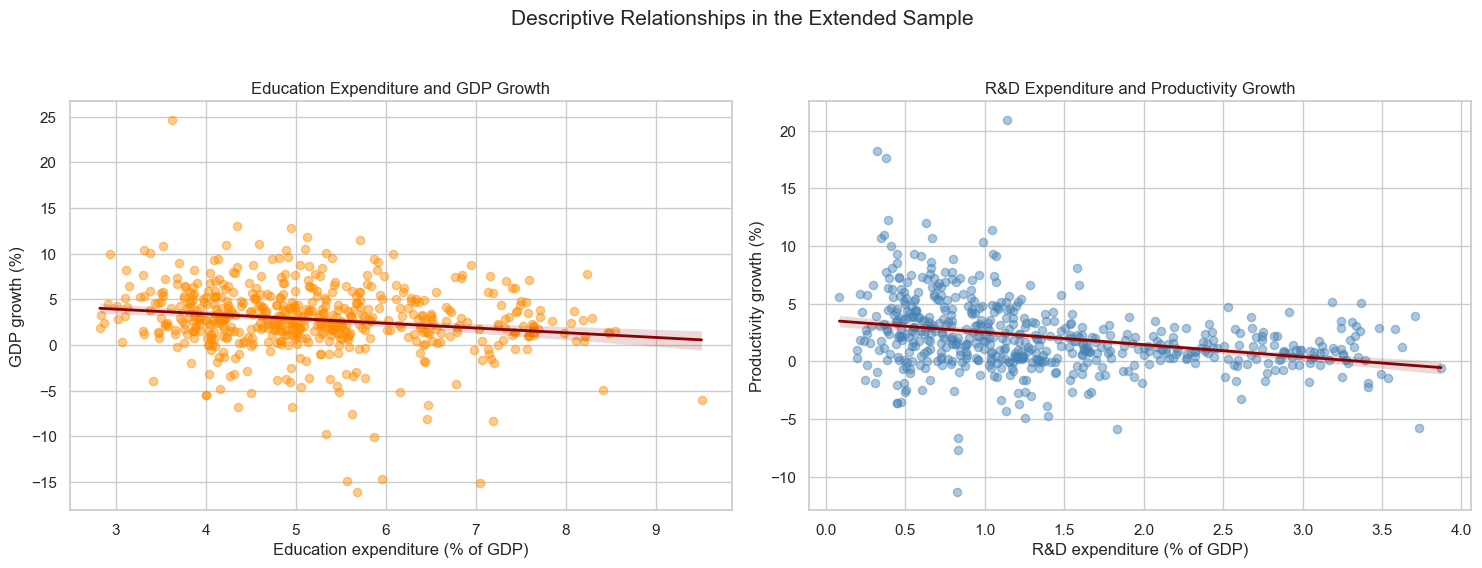

In [6]:
# Two focused descriptive plots for the added variables.
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5.5))

sns.regplot(
    data=complete_case,
    x="Education Expenditure",
    y="GDP Growth",
    scatter_kws={"alpha": 0.45, "s": 35, "color": "darkorange"},
    line_kws={"color": "darkred", "linewidth": 2},
    ax=axes[0]
)
axes[0].set_title("Education Expenditure and GDP Growth")
axes[0].set_xlabel("Education expenditure (% of GDP)")
axes[0].set_ylabel("GDP growth (%)")

sns.regplot(
    data=complete_case,
    x="R&D Expenditure",
    y="Productivity Growth",
    scatter_kws={"alpha": 0.45, "s": 35, "color": "steelblue"},
    line_kws={"color": "darkred", "linewidth": 2},
    ax=axes[1]
)
axes[1].set_title("R&D Expenditure and Productivity Growth")
axes[1].set_xlabel("R&D expenditure (% of GDP)")
axes[1].set_ylabel("Productivity growth (%)")

plt.suptitle(
    "Descriptive Relationships in the Extended Sample",
    fontsize=15,
    y=1.03
)
plt.tight_layout()
plt.show()

*Source: World Bank World Development Indicators (`SE.XPD.TOTL.GD.ZS` and `GB.XPD.RSDV.GD.ZS`) and the World Bank Aggregate and Sector Productivity Database, 2000–2018. These plots are descriptive associations, not causal estimates.*

## 4. Same-sample two-way fixed-effects models

Both models use country and year fixed effects, with standard errors clustered by country, exactly as in Notebook 04. The restricted baseline contains productivity growth and investment. The extended model adds education and R&D expenditure.

The comparison is fair because **both models are estimated on exactly the same complete-case country-years**. The restricted model here is therefore not the same as Notebook 04's original 779-observation main model.

In [7]:
# Arrange the common sample as a panel. No constant is added because
# country and year fixed effects absorb the intercept.
panel = (
    complete_case
    .sort_values(["Country Code", "Year"])
    .set_index(["Country Code", "Year"])
)

if not panel.index.is_unique:
    raise ValueError("The regression panel has duplicate country-year keys.")

dependent_variable = "GDP Growth"
restricted_variables = [
    "Productivity Growth",
    "Investment"
]
extended_variables = [
    "Productivity Growth",
    "Investment",
    "Education Expenditure",
    "R&D Expenditure"
]

y = panel[dependent_variable]
X_restricted = panel[restricted_variables]
X_extended = panel[extended_variables]

print("Regression observations:", len(panel))
print("Countries:", panel.index.get_level_values("Country Code").nunique())
print("Period:", panel.index.get_level_values("Year").min(), "-", panel.index.get_level_values("Year").max())

restricted_model = PanelOLS(
    dependent=y,
    exog=X_restricted,
    entity_effects=True,
    time_effects=True
)

extended_model = PanelOLS(
    dependent=y,
    exog=X_extended,
    entity_effects=True,
    time_effects=True
)

restricted_results = restricted_model.fit(
    cov_type="clustered",
    cluster_entity=True
)

extended_results = extended_model.fit(
    cov_type="clustered",
    cluster_entity=True
)

Regression observations: 574
Countries: 40
Period: 2000 - 2018


In [8]:
# Present the two models in a compact, readable table.
def extract_model_results(result, model_name):
    """Extract coefficients and country-clustered inference statistics."""
    return pd.DataFrame({
        "Model": model_name,
        "Variable": result.params.index,
        "Coefficient": result.params.values,
        "Standard Error": result.std_errors.values,
        "t-statistic": result.tstats.values,
        "p-value": result.pvalues.values
    })

coefficient_table = pd.concat(
    [
        extract_model_results(
            restricted_results,
            "Restricted baseline (common sample)"
        ),
        extract_model_results(
            extended_results,
            "Extended model"
        )
    ],
    ignore_index=True
)

variable_order = pd.CategoricalDtype(
    categories=extended_variables,
    ordered=True
)
coefficient_table["Variable"] = coefficient_table["Variable"].astype(variable_order)
coefficient_table = coefficient_table.sort_values(["Variable", "Model"])

display(coefficient_table.round(4))

model_summary = pd.DataFrame({
    "Model": [
        "Restricted baseline (common sample)",
        "Extended model"
    ],
    "Observations": [restricted_results.nobs, extended_results.nobs],
    "Countries": [
        panel.index.get_level_values("Country Code").nunique(),
        panel.index.get_level_values("Country Code").nunique()
    ],
    "Years": [
        panel.index.get_level_values("Year").nunique(),
        panel.index.get_level_values("Year").nunique()
    ],
    "Within R-squared": [
        restricted_results.rsquared_within,
        extended_results.rsquared_within
    ],
    "Country fixed effects": ["Yes", "Yes"],
    "Year fixed effects": ["Yes", "Yes"],
    "Country-clustered standard errors": ["Yes", "Yes"]
})

display(model_summary.round(4))

,Model,Variable,Coefficient,Standard Error,t-statistic,p-value
2,Extended model,Productivity Growth,0.7086,0.0767,9.2377,0.0000
0,Restricted baseline (common sample),Productivity Growth,0.7130,0.0797,8.9480,0.0000
3,Extended model,Investment,0.2503,0.0391,6.4046,0.0000
1,Restricted baseline (common sample),Investment,0.2484,0.0372,6.6851,0.0000
4,Extended model,Education Expenditure,-0.5266,0.2471,-2.1309,0.0336
5,Extended model,R&D Expenditure,0.3767,0.7331,0.5138,0.6076


,Model,Observations,Countries,Years,Within R-squared,Country fixed effects,Year fixed effects,Country-clustered standard errors
0,Restricted baseline (common sample),574,40,19,0.5799,Yes,Yes,Yes
1,Extended model,574,40,19,0.5980,Yes,Yes,Yes


## 5. Results and interpretation

The following short interpretation is generated from the fitted extended model. A positive coefficient means that a higher value of the variable is associated with higher GDP growth, conditional on the other included variables and the country and year fixed effects. It does **not** show that changing the variable would cause GDP growth to change.

In [9]:
# Generate a cautious, data-driven interpretation of the two estimates.
def association_sentence(result, variable, description):
    coefficient = float(result.params[variable])
    p_value = float(result.pvalues[variable])
    direction = "higher" if coefficient >= 0 else "lower"
    evidence = (
        "is statistically distinguishable from zero at the 5% level"
        if p_value < 0.05
        else "is not statistically distinguishable from zero at the 5% level"
    )

    return (
        f"For a one-percentage-point increase in {description}, the extended model estimates "
        f"approximately {abs(coefficient):.3f} percentage points {direction} GDP growth. "
        f"This conditional association {evidence} (p = {p_value:.4f})."
    )

restricted_productivity = float(restricted_results.params["Productivity Growth"])
extended_productivity = float(extended_results.params["Productivity Growth"])
restricted_investment = float(restricted_results.params["Investment"])
extended_investment = float(extended_results.params["Investment"])

within_r2_change = (
    extended_results.rsquared_within
    - restricted_results.rsquared_within
)

interpretation = f"""
### Reading the same-sample comparison

Both models use **{int(extended_results.nobs)} country-year observations**, so the changes in the productivity and investment coefficients are comparable within this restricted sample. Productivity changes from **{restricted_productivity:.3f}** in the restricted model to **{extended_productivity:.3f}** after education and R&D are added. Investment changes from **{restricted_investment:.3f}** to **{extended_investment:.3f}**.

{association_sentence(extended_results, "Education Expenditure", "education expenditure as a share of GDP")}

{association_sentence(extended_results, "R&D Expenditure", "R&D expenditure as a share of GDP")}

The within R-squared changes by **{within_r2_change:.4f}** when education and R&D are added. This is a descriptive comparison of model fit, not a causal test of their economic importance. Education and R&D may also influence growth through productivity, so their coefficients measure conditional contemporaneous associations beyond productivity growth rather than their total long-run contribution.

Education and R&D can take years to influence skills, technology, and output. Therefore, even a weak or statistically imprecise contemporaneous coefficient should not be interpreted as evidence that the variable is economically unimportant.
"""

display(Markdown(interpretation))


### Reading the same-sample comparison

Both models use **574 country-year observations**, so the changes in the productivity and investment coefficients are comparable within this restricted sample. Productivity changes from **0.713** in the restricted model to **0.709** after education and R&D are added. Investment changes from **0.248** to **0.250**.

For a one-percentage-point increase in education expenditure as a share of GDP, the extended model estimates approximately 0.527 percentage points lower GDP growth. This conditional association is statistically distinguishable from zero at the 5% level (p = 0.0336).

For a one-percentage-point increase in R&D expenditure as a share of GDP, the extended model estimates approximately 0.377 percentage points higher GDP growth. This conditional association is not statistically distinguishable from zero at the 5% level (p = 0.6076).

The within R-squared changes by **0.0181** when education and R&D are added. This is a descriptive comparison of model fit, not a causal test of their economic importance. Education and R&D may also influence growth through productivity, so their coefficients measure conditional contemporaneous associations beyond productivity growth rather than their total long-run contribution.

Education and R&D can take years to influence skills, technology, and output. Therefore, even a weak or statistically imprecise contemporaneous coefficient should not be interpreted as evidence that the variable is economically unimportant.


## 6. Positives and limitations

### Positives

- The extension broadens the economic story by including **human-capital investment** (education) and **innovation investment** (R&D).
- It uses a multi-country European panel and the same country and year fixed-effects approach as the main analysis.
- The restricted and extended regressions use the **same complete-case sample**, making the comparison transparent.
- Country fixed effects, year fixed effects, and country-clustered standard errors help account for persistent national differences, common annual shocks, and repeated observations within countries.
- The original balanced core model is retained, so the additional variables do not silently reduce the main project sample.

### Limitations

- The results show **associations**, not causal effects. Reverse causality and omitted time-varying factors may remain.
- Missing education and R&D values reduce the extension to a smaller, unbalanced sample; some countries contribute only a few country-years.
- Education and R&D expenditure may affect growth only after long lags, which this contemporaneous model does not capture.
- Other determinants of growth are omitted, including institutions, trade, demographics, business conditions, and sectoral structure.
- Education and R&D can partly operate through productivity, so their coefficients should not be interpreted as their complete long-run contribution to growth.
- GDP growth is volatile and can be strongly affected by shocks that annual expenditure measures do not fully capture.

## 7. Final conclusion

This extension investigates whether education and innovation expenditure complement productivity growth and investment in explaining GDP growth across European countries. It provides a broader economic perspective while preserving the original balanced productivity–investment model as the project’s main evidence.

Although this analysis does not establish that education or R&D expenditure directly causes higher annual GDP growth, they remain important areas for policy. Investment in education can strengthen human capital, while R&D funding can support innovation, technology adoption, and future productivity improvements. These benefits are likely to emerge gradually and may not be fully captured by a contemporaneous growth model. Therefore, European policymakers should view education and R&D expenditure as long-term strategic investments that can help create the conditions for sustainable productivity and economic growth, alongside policies that support private investment and efficient resource allocation. For this reason, it was important to include this section in this project. 